<a href="https://colab.research.google.com/github/ahmdbnrsl/Machine-Learning/blob/main/Mathematics-Requirements/Maths_For_ML/Matrix_Calculus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

$\textbf{Matrix Calculus}$

$\text{1.1 Turunan Pertama}$

$\text{a. Turunan sebagai linearisasi}$

Di kalkulus satu variabel (skalar), turunan sering kali didefinisikan secara sederhana sebagai linierisasi dari sebuah fungsi.
Artinya, untuk perubahan $x$ yang sangat kecil, perubahan fungsinya bisa dihampiri dengan garis lurus: $$f(x) - f(x_0) \approx f'(x_0)(x - x_0)$$ Teks memberikan beberapa pilihan notasi untuk linierisasi ini, namun yang paling direkomendasikan (diutamakan) untuk kelas ini adalah:$$df = f'(x)dx$$Di sini, $dx$ dan $dy$ (atau $df$) dianggap sebagai angka yang "sangat kecil" (disebut infinitesimals dalam matematika).

$\text{b. Aturan Emas: Jangan Membagi dengan }dx!$

Ini adalah poin transisi yang sangat penting! Dalam kalkulus skalar, kita sering membagi $dy$ dengan $dx$ sehingga menjadi $\frac{dy}{dx}$. Namun, teks ini memberikan peringatan keras: jangan membagi dengan $dx$! Alasannya: Meskipun pembagian ini sah-sah saja untuk skalar, begitu kita masuk ke dunia vektor dan matriks, kita tidak selalu bisa membagi dengan sebuah vektor atau matriks. Oleh karena itu, kita mempertahankan bentuk perkalian $f'(x)dx$.

$\text{c. Perubahan "Bentuk" (Shape) dari Turunan}$

Saat kita meninggalkan dunia skalar dan memandang matriks secara holistik, konsep linierisasi tetap berlaku. Namun, turunan tidak lagi sekadar angka tunggal; turunan akan memiliki "bentuk" (shape) yang berbeda tergantung pada input dan outputnya.Teks memberikan tabel yang sangat penting untuk mengingat bentuk turunan:

- Input Skalar $\rightarrow$ Output Vektor = Turunannya berupa Vektor (contoh: kecepatan).
- Input Vektor $\rightarrow$ Output Skalar = Turunannya berupa Gradien (vektor kolom).
- Input Vektor $\rightarrow$ Output Vektor = Turunannya berupa Matriks (disebut Jacobian matrix).
- Input Matriks $\rightarrow$ Output Skalar = Turunannya berupa Matriks.

$\text{d. Pembuktian Konsep (Example 1)}$

Teks menutup bagian ini dengan sebuah contoh untuk membuktikan bahwa konsep diferensial sebagai linierisasi ini benar-benar bekerja.

Diberikan fungsi $f(x) = x^T x$, dengan input $x$ berupa vektor (matriks $2 \times 1$) dan output skalar (matriks $1 \times 1$). Titik awalnya adalah $x_0 = \begin{pmatrix} 3 \\ 4 \end{pmatrix}$.

- Nilai awal: $f(x_0) = 3^2 + 4^2 = 25$.
- Diberi gangguan kecil ($dx$): Misal $dx = \begin{pmatrix} 0.001 \\ 0.002 \end{pmatrix}$. Jika kita hitung nilai asli dari $f(x_0 + dx)$, hasilnya adalah $25.022005$.
- Menggunakan hampiran turunan: Teks menyatakan (dan akan dibuktikan nanti) bahwa diferensialnya adalah $2x_0^T dx$. Jika kita hitung nilainya: $2(3 \quad 4) \begin{pmatrix} 0.001 \\ 0.002 \end{pmatrix} = 0.022$.
- Kesimpulan: Selisih fungsinya $f(x_0 + dx) - f(x_0)$ adalah sekitar $0.022$, yang ternyata sangat cocok dengan hasil perhitungan diferensial kita ($2x_0^T dx = 0.022$). Ini membuktikan bahwa bentuk diferensial tersebut "tidak muncul begitu saja", melainkan benar-benar mewakili hampiran liniernya.

In [ ]:
import sympy as sp

def f(x: sp.matrices.dense.MutableDenseMatrix) -> float:
    return x.dot(x)

x_0 = sp.Matrix([3, 4])

dx = sp.Matrix([0.001, 0.002])

print(f(x_0 + dx) - f(x_0),
      2*x_0.dot(dx),
      f(x_0 + dx) - f(x_0),
      2*x_0.transpose().dot(x_0 + dx - x_0))

0.0220050000000001 0.0220000000000000 0.0220050000000001 0.0219999999999976


$\text{1.2 Perkalian Matriks}$

Tidak sama seperti perkalian skalar dan vektor, dimana dalam perkalian tersebut kita bisa terapkan sifat komutatif atau diubah urutannya, dalam matrix multiplication perubahan posisi perkalian akan mengubah hasilnya

In [ ]:
import numpy as np
a, b = np.array([1, 2]), np.array([3, 4])
a.T, b

(array([1, 2]), array([3, 4]))

Perkalian vektor kolom dan veektor baris, akan menghasilkan matrriks, jadi kita tidak di perbolehkan mengubah urutan perkaliannya.

In [ ]:
import sympy as sp
a = sp.Matrix([1, 2])
b = sp.Matrix([2, 4]).transpose()

a @ b, b @ a

(Matrix([
 [2, 4],
 [4, 8]]),
 Matrix([[10]]))

In [ ]:
import numpy as np
A = np.array([[1, 2], [2, 2]])
B = np.array([[2, 4], [1, 3]])

A @ B, B @ A

(array([[ 4, 10],
        [ 6, 14]]),
 array([[10, 12],
        [ 7,  8]]))

$\text{Perbedaan}\ \delta x \text{ dan }dx$

- $\delta x$ ini adalah perubahan fisik nyata, misal dari $x = 1$ ke $x = 1.00002$ maka $\delta x = 0.00002$
- $dx$ adalah infinitesimal, dimana ini adalah ukuran anak tangga perubahan $x$ yang sangat kecil mendekati $0$ tapi bukan $0$. Atau dalam kata lain anggap saja sebuah kurva dari fungsi kita pecah menjadi bagian atau persegi panjang yang lebar nya sangat kecil, lebar itulah yang kita sebut $dx$ dan tingginya adalah $f(x)$.

"Transpose itu hanya mengikuti" artinya jika fungsi di transpose maka turunannya juga di transpose, dan sebaliknya.

Dalam kalkulus biasa kita sering menuliskan notasi turunan sebagai pecahan $\frac{df(x)}{dx}$, dalam matrix kalkulus, sebaiknya kita tidak menggunakan notasi pecahan tersebut, karena bisa saja output kita matrix sedang kan input kita vector, artinya kita membagi matrix dengan vector, itu tidak akan valid, maka dari itu notasi turunan dalam matrix kalkulus ini, di modifikasi melalui aljabar dibawah ini:

$$\begin{aligned}
& \text{kita tahu bahwa }\frac{df(x)}{dx} = f'(x)\\
& \text{dalam matrix calculus, kita memodifikasi nya menjadi bentuk perkalian}\\
& df(x) = f'(x)dx
\end{aligned}$$

nah dalam bentuk yang seperti ini, kita tidak akan melibatkan pembagian matrix dengan vector.

Dari notasi diatas dirombak lagi menjadi $$df = f'(x)[dx]$$ ini menjadikan $f'(x)$ sebagai operatir linier dan $dx$ menjadi inputnya.

kita tidak boleh menuliskan notasi nya dalam bentuk $$df = dxf'(x)$$ karena itu tidak valid dalam matematika

operator linier dalam kasus ini harus memiliki 2 syarat

- Linearitas: $L[a + b] = L[a] + L[b]$
- Homogeneous: $L[\alpha v] = \alpha L[v]$, dimana $\alpha$ adalah sembarang scalar.

$\text{Notasi}$

Ada beberapa notasi turunan

- Notasi umum: $f'(x),\ \frac{dy}{dx},\ D_xf,\ \nabla f,\ \partial f$
- Partial derivative: $\partial{f}$
- Perubahan Nyata: $\delta f,\ f(x + \delta x) - f(x) = f'(x)\delta x$
- Turunan 1 variable: $df,\ f(x + dx) - f(x) = f'(x)dx$
- Gradient: $\nabla f$, gradient ini berupa vektor, $dx$ nya pun vektor, dimana kalau $\nabla f$ di operasikan inner product dengan $dx$ (seberapa jauh perubahan input) akan menghasilkan scalar, itulah $df$ atau seberapa jauh perubahan outputnya.

apa sih sebenernya $dx$ itu? $dx$ adalah infinitesimal atau langkah maju yang sangat kecil dari input, sedangkan $dy$ adalah langkah output yang dihasilkan oleh input $x + dx$ dikurangi output sebelumnya $f$.

pendekatan dengan limit, kita tau bahwa $df = f(x + dx) - f(x)$

maka limit nya: $$\lim_{dx \to 0} \frac{df}{dx}$$

nah inilah yang kita kenal dengan notasi $\frac{df}{dx}$ atau $\frac{dy}{dx}$.

tapi dalam matrix kalkulus notasinya kita ubah menjadi $df = f'(x)dx$ supaya tidak melibatkan pembagian dengan matrix maupun vector.

$\text{Fungsi Affine}$

Jika selama dalam materi kalkulus biasa kita menyebut fungsi $f(x) = x + 1$ sebagai fungsi linear, karena memiliki grafik yang lurus, dalam aljabar linier itu salah besar, karena syarat fungsi linier adalah harus memenuhi syarat homogen, dimana $f(\alpha x) = \alpha f(x)$, nah kalau kita tes $f(x) = x + 1$ kita kalikan $x$ dan $f(x)$ dengan sembarang skalar misal $2$, saat x dikalikan $2$ akan menjadi $f(2x) = 2x + 1$ sedangkan saat $f(x)$ dikali $2$ akan menjadi $2(x + 1) = 2x + 2$, kedua hasil ini jelas berbeda dan menandakan bahwa ini melanggar syarat homogen. Lalu jika bukan linier namanya apa? sedangkan grafiknya terbukti linier, **Fungsi Affine** adalah yang disematkan untuk kategori fungsi seperti ini, fungsi linier yang ditambah konstanta.

$\text{Turunan Berarah}$

kita tau bahwa $df$ samadengan $f'(x)[dx]$ dimana operator $f'(x)$ menerima input $dx$, jika kita berikan input vektor biasa kedalam input operator $f'(x)$ maka hasil nya akan menjadi turunan yang memiliki arah. Maka notasinya akan menjadi seperti ini $df = f'(x)[v\cdot d\alpha]$, dimana $v$ adalah vektor biasa (non-infinitesimal) yang memberitahu arahnya. dan $d\alpha$ adalah skalar infinitesimal nya yang memberitahu seberapa jauh langkahnya. $f(x + \underbrace{d\alpha\cdot v}_{dx})− f(x) = f′(x)[dx] = dα f′(x)[v]$

$\text{Aturan Bentuk Turunan}$

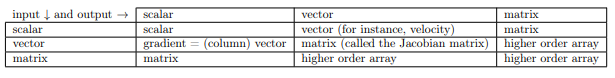

In [19]:
# Contoh pada softmax function, ketika input vector dan output vector, maka turunannya adalah matriks jacobian
import numpy as np

def softmax(z):
    return np.exp(z) / np.sum(np.exp(z))

def softmax_grad(z):
    jacobian = []
    for i in range(len(z)):
        gradient = []
        for j in range(len(z)):
            if i == j:
                gradient.append(softmax(z)[i] * (1 - softmax(z)[i]))
            elif i != j:
                gradient.append(-softmax(z)[i] * softmax(z)[j])
        jacobian.append(gradient)

    return np.array(jacobian)

z = np.array([1, 2, 3])

jacobian = softmax_grad(z)

softmax(z), jacobian

(array([0.09003057, 0.24472847, 0.66524096]),
 array([[ 0.08192507, -0.02203304, -0.05989202],
        [-0.02203304,  0.18483645, -0.1628034 ],
        [-0.05989202, -0.1628034 ,  0.22269543]]))